Test the perturbed slab model created.

In [3]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
from fields.slab_bfield_one_pert import SlabBfieldOnePert
from pyoculus.maps import ToroidalBfieldSection
from pyoculus.solvers import PoincarePlot, FixedPoint
import matplotlib.pyplot as plt

#### Create the magnetic field:

In [4]:
field = SlabBfieldOnePert(
    m=3,
    n=2,
    delta=0.01,
    iota_prime=1.0,
    x0=0,
)


xs = field.x0 + field.n / (field.iota_prime * field.m)

coords = np.array([0.4, 0.2, 0.3])

print("The island will be situated at x_s =", xs)

The island will be situated at x_s = 0.6666666666666666


#### Create the map:

In [5]:
map = ToroidalBfieldSection(field)

#### Create Poincaré plot:

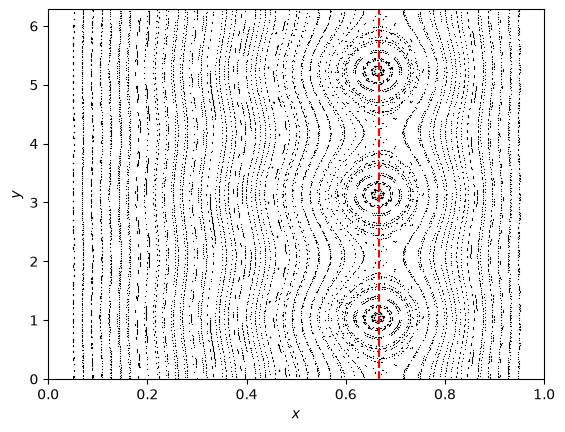

In [7]:
pplot = PoincarePlot.with_segments(
    map,
    np.array([
        [0.05, 1.0],
        [0.95, 1.0],
        [0.05, np.pi],
        [0.95, np.pi],
        [0.05, 3*np.pi/2],
        [0.95, 3*np.pi/2],
    ]),
    neps=[50, 50, 50],
    connected=False,
)

# Follow each initial condition for 200 crossings
pplot.compute(npts=100)

# Plot directly in (x,y) coordinates
fig, ax = pplot.plot(plottype=None) # plottypeNone to directly plot in the coordinates of the map

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 2*np.pi)

xs = field.x0 + field.n / (field.iota_prime * field.m)

ax.axvline(
    xs,
    linestyle="--",
    label=rf"$x_s={xs:.3f}$",
    color="r"
)

plt.show()

#### Find fixed points:

In [8]:
# Find a t-periodic point
fp = FixedPoint(map)

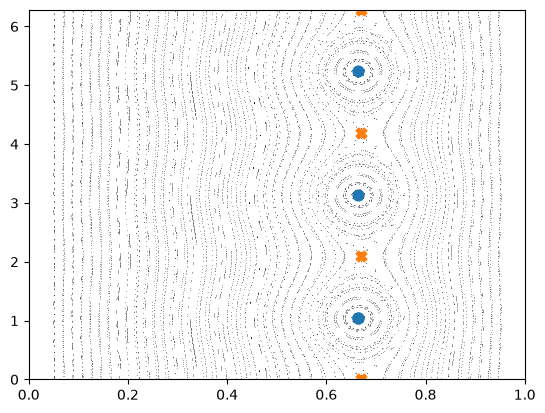

In [9]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 1.],
    ylim=[0, 2*np.pi],
    plottype=None
)


fp = FixedPoint(map)

# Elliptic FP / O-points:
result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.66, 1.3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

# Hyperbolic FP / X-points:
result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.66, 6.3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)


plt.show()

#### Wrong cases:

```fp.find(t=t,...)``` doesn't always work: sometimes we stumble upon t-cycles that aren't fixed points.

[[0.51191976 4.38959195]
 [0.48820761 1.28449852]
 [0.51191976 4.38959195]
 [0.48820761 1.28449852]
 [0.51191976 4.38959195]]


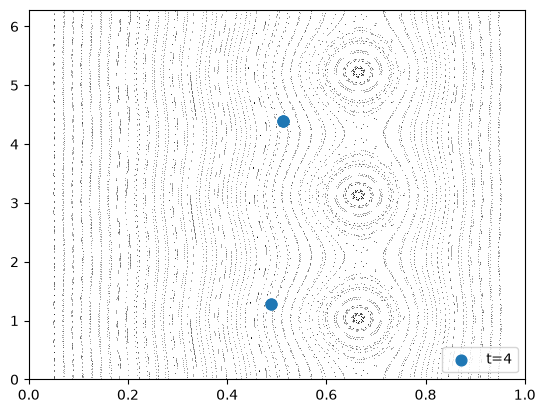

In [10]:
guess = np.array([xs, 4])
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 1.],
    ylim=[0, 2*np.pi],
    plottype=None
)

for t in [4]:
    fp = FixedPoint(map)
    result = fp.find(
        t=t,                    # t-order fixed points
        guess=guess,
        method="scipy.root"
    ) 
    print(result.coords)     

    fp.plot(
        fig=fig,
        ax=ax,
        s=60,
        label=f"t={t}",
        plottype=None
    )

plt.legend(loc="lower right")
plt.show()
